In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import jit, vmap, grad
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from jax import random
import jax
import time
from tqdm import tqdm

In [53]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, input_dim, hidden_dim):
  subkey1, subkey2 = random.split(key)
  params = {
      'W1': random.normal(subkey1, (hidden_dim, input_dim)) * 1.0,
      'b1': jnp.zeros(hidden_dim),
      'W2': random.normal(subkey2, (1, hidden_dim)) * 1.0,
      'b2': jnp.zeros(1),
  }
  return params

@jit
def forward(params, z):
  h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  # h = jax.nn.elu(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
  return y.squeeze()

def forward_(X, z, unravel_fn):
  E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
  return E

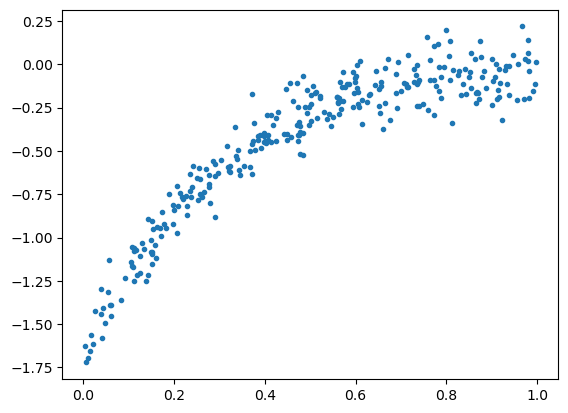

In [54]:
def target_function(z):
  params = jnp.array([2, 0.5, 3, -3])
  return params[2]*jnp.tanh(params[0]*z.squeeze()+params[1]) + params[3]
  # params = jnp.array([2, -0.5, 3, -3])
  # return params[2]*jnp.tanh(params[0]*z.squeeze()-params[1]) + params[3]
  # return (z.squeeze())**2
  # return jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]
    Y_clean = target_function(Z)
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y = Y_clean + noise
    return Z, Y

s = 1 #input dimension
key = random.PRNGKey(1003)
key, subkey = random.split(key)
N = 300
Z, Y = generate_data(subkey, s, N=N, noise_std=0.1) # put more noise
device = jax.devices()[0]
Z, Y = jax.device_put((Z, Y), device)
plt.plot(Z,Y,".")

In [69]:
def log_q0(x, cov=0.5):
  return multivariate_normal.logpdf(x, jnp.zeros_like(x), cov)

def L(X, unravel_fn, gamma=100):
    n = len(X)
    Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
    return gamma * jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

# This part is required to obtain unravel_fn
hidden_dim = 1
params = init_params(key, s, hidden_dim)
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)

# q0cov = 1
# log_q0_ = lambda x: log_q0(x, q0cov)
gamma = 300
L_ = jit(lambda X: L(X, unravel_fn, gamma))
S_q0 = jit(vmap(grad(log_q0)))
gradL = jit(grad(lambda X : L_(X)*len(X)))
score = lambda X: S_q0(X) - gradL(X)

In [70]:
class GradientKernel:
    def __init__(self, S_PQ, k):
        self.S_PQ = S_PQ
        self.k = jit(k)
        self.dkx = jit(jacrev(self.k, argnums=0))
        self.dky = jit(jacrev(self.k, argnums=1))
        self.d2k = jit(jacfwd(self.dky, argnums=0))
        self.K = lambda X : vmap(lambda x: vmap(lambda y: self.k(x, y))(X))(X)
        self.dKx = lambda X : vmap(lambda x: vmap(lambda y: self.dkx(x, y))(X))(X)
        self.d2K = lambda X : vmap(lambda x: vmap(lambda y: jnp.trace(self.d2k(x, y)))(X))(X)


    def evaluate(self, X):
        K = self.K(X)
        dK = self.dKx(X)
        d2K = self.d2K(X)
        S_PQ = self.S_PQ(X)
        S_dK = jnp.einsum('ijk, ijk -> ij', dK, (S_PQ[None, :, :]))
        k_pq = d2K + S_dK + S_dK.T + K * jnp.dot(S_PQ, S_PQ.T)
        return k_pq


def kgd(k_pq, X):
  return k_pq.evaluate(X).mean()

def k_imq(x, y, c, b, scale=1.):
  assert b > 0
  return (c**2 + (x-y).dot(x-y)/scale**2)**(-b)

def imq_scale_mixtures(x, y, scales):
  return  vmap(lambda scale: k_imq(x, y, 1, 0.5, scale))(scales).mean()

In [71]:
# @title Default title text
def gL(x, X, unravel_fn, gamma):
  Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
  # x = X[0]
  g = jax.grad(lambda x, z: forward(unravel_fn(x), z), 0)
  # print(g(x, Z[0]).shape)
  G = vmap(lambda z: g(x, z))(Z)
  # print(G.shape)
  diff= ( Y -Esp_forward )[:, None]
  result = (diff * G).mean(axis = 0)
  # print(result.shape)
  return -2*gamma * result

def stein_kernel(x, y, X, k, q0_score, unravel_fn, gamma):
  gL_ = lambda x: gL(x, X, unravel_fn, gamma)
  dkx = jit(jacrev(k, argnums=0))
  dky = jit(jacrev(k, argnums=1))
  d2k = jit(jacfwd(dky, argnums=0))
  bx = q0_score(x) - gL_(x)
  by = q0_score(y) - gL_(y)
  return bx.dot(by)* k(x, y) + dkx(x, y).dot(by) + dky(x, y).dot(bx) + jnp.trace(d2k(x, y))

def kgd_descent(kgd_fn, X0, eta, T):
  X = X0.copy()
  for step in range(T):
    g = grad(kgd_fn)(X)
    X = X - eta * g
    if step % 100 == 0:
      print(step, kgd_fn(X), L_(X))
  return X


def kgd_descent_adam(kgd_fn, X0, lr=1e-3, T=1000):
    """
    Run Adam optimization on the KGD objective wrt particles X.
    """
    tx = optax.adam(lr)
    opt_state = tx.init(X0)

    X = X0
    loss_and_grad = jax.jit(jax.value_and_grad(kgd_fn))
    particles = [X]

    losses = []
    for step in range(T):
        loss_val, g = loss_and_grad(X)
        updates, opt_state = tx.update(g, opt_state)
        X = optax.apply_updates(X, updates)
        particles.append(X)

        if step % 10 == 0:
            mse = L_(X) / gamma   # if you want MSE logging
            print(f"Step {step}, loss = {loss_val}, mse = {mse}")
            losses.append(loss_val)
          

    return particles#, jnp.array(losses)

In [83]:
import optax
T = 20000
num_particles = 100

num_stepsizes = 10
etas = jnp.logspace(-4, -1, num_stepsizes)
# num_stepsizes = 1
# etas = jnp.array([5e-3])
d = len(flat_params)
device = jax.devices()[0]

final_particles = jnp.empty((num_stepsizes, num_particles, d))

key, subkey = random.split(key)
init_std = 3
X0 = init_std*random.normal(subkey, shape=(num_particles, d))
X0 = jax.device_put(X0, device)


scale = 1e+0
k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))
# k = jit(lambda x, y: imq_scale_mixtures(x, y, jnp.logspace(-2, 2, 5)))
# k = lambda x, y: x.dot(y)
# kgdd = KGDDescent(log_q0, k, unravel_fn, gamma)
k_mod = GradientKernel(score, k)
kgd_ = jit(lambda X: kgd(k_mod, X)**0.5)
# kgd_ = jit(lambda X: kgd(k_mod, X))

for e, eta in (enumerate(tqdm(etas))):
  key, subkey = random.split(key)
  #Xfinal = kgd_descent(kgd_, X0, eta, T)
  Xfinal = kgd_descent_adam(kgd_, X0, eta, T)[-1]
  final_particles = final_particles.at[e].set(Xfinal)

  0%|          | 0/10 [00:00<?, ?it/s]

Step 0, loss = 300.4704284667969, mse = 1.3257999420166016
Step 10, loss = 299.7030334472656, mse = 1.3198943138122559
Step 20, loss = 298.9358215332031, mse = 1.3140029907226562
Step 30, loss = 298.16876220703125, mse = 1.3081259727478027
Step 40, loss = 297.40191650390625, mse = 1.3022637367248535
Step 50, loss = 296.6353759765625, mse = 1.2964154481887817
Step 60, loss = 295.8689270019531, mse = 1.2905813455581665
Step 70, loss = 295.102783203125, mse = 1.284761667251587
Step 80, loss = 294.3369140625, mse = 1.2789560556411743
Step 90, loss = 293.5711364746094, mse = 1.2731647491455078
Step 100, loss = 292.8056945800781, mse = 1.2673879861831665
Step 110, loss = 292.0404052734375, mse = 1.2616256475448608
Step 120, loss = 291.27545166015625, mse = 1.2558778524398804
Step 130, loss = 290.5107421875, mse = 1.2501447200775146
Step 140, loss = 289.7461853027344, mse = 1.2444260120391846
Step 150, loss = 288.9818420410156, mse = 1.2387217283248901
Step 160, loss = 288.2177734375, mse = 1

 10%|█         | 1/10 [00:25<03:46, 25.14s/it]

Step 19910, loss = 1.7016685009002686, mse = 0.01455723401159048
Step 19920, loss = 1.700980544090271, mse = 0.014551954343914986
Step 19930, loss = 1.7002860307693481, mse = 0.014546668156981468
Step 19940, loss = 1.6995975971221924, mse = 0.014541457407176495
Step 19950, loss = 1.6989129781723022, mse = 0.014536277391016483
Step 19960, loss = 1.698231816291809, mse = 0.014531135559082031
Step 19970, loss = 1.6975511312484741, mse = 0.014526043087244034
Step 19980, loss = 1.6968718767166138, mse = 0.01452099159359932
Step 19990, loss = 1.696193814277649, mse = 0.014515980146825314
Step 0, loss = 300.4704284667969, mse = 1.3251169919967651
Step 10, loss = 298.81707763671875, mse = 1.3124140501022339
Step 20, loss = 297.1646728515625, mse = 1.299780011177063
Step 30, loss = 295.5132141113281, mse = 1.2872138023376465
Step 40, loss = 293.8628845214844, mse = 1.2747150659561157
Step 50, loss = 292.2135925292969, mse = 1.2622835636138916
Step 60, loss = 290.56549072265625, mse = 1.24991965

 20%|██        | 2/10 [00:49<03:19, 24.95s/it]

...

 80%|████████  | 8/10 [04:18<01:16, 38.01s/it]

Step 0, loss = 300.4704284667969, mse = 1.0681822299957275
Step 10, loss = 35.7933349609375, mse = 0.18593084812164307
Step 20, loss = 13.927755355834961, mse = 0.1451001912355423
Step 30, loss = 15.763601303100586, mse = 0.14031420648097992
Step 40, loss = 15.841476440429688, mse = 0.12677624821662903
Step 50, loss = 10.68603515625, mse = 0.11569015681743622
Step 60, loss = 8.969037055969238, mse = 0.10506045818328857
Step 70, loss = 8.145430564880371, mse = 0.09535245597362518
Step 80, loss = 7.176855564117432, mse = 0.08652859181165695
Step 90, loss = 6.557844638824463, mse = 0.07820168137550354
Step 100, loss = 5.955348014831543, mse = 0.07035480439662933
Step 110, loss = 5.407644271850586, mse = 0.06305854767560959
Step 120, loss = 4.916120529174805, mse = 0.056309774518013
Step 130, loss = 4.462467670440674, mse = 0.05008914694190025
Step 140, loss = 4.046994209289551, mse = 0.044412340968847275
Step 150, loss = 3.6715035438537598, mse = 0.03924970701336861
Step 160, loss = 3.320

 90%|█████████ | 9/10 [04:43<00:33, 33.96s/it]

Step 0, loss = 300.4704284667969, mse = 0.8106479048728943
Step 10, loss = 64.58783721923828, mse = 0.16823922097682953
Step 20, loss = 11.656716346740723, mse = 0.1470494270324707
Step 30, loss = 21.397878646850586, mse = 0.13452491164207458
Step 40, loss = 13.473526000976562, mse = 0.12280574440956116
Step 50, loss = 7.950362205505371, mse = 0.1131698489189148
Step 60, loss = 6.806058406829834, mse = 0.1021471619606018
Step 70, loss = 6.067692756652832, mse = 0.09231412410736084
Step 80, loss = 5.316571235656738, mse = 0.08304807543754578
Step 90, loss = 4.778213024139404, mse = 0.07441580295562744
Step 100, loss = 4.321808815002441, mse = 0.06647498160600662
Step 110, loss = 3.914752960205078, mse = 0.059253718703985214
Step 120, loss = 3.5696074962615967, mse = 0.05275876820087433
Step 130, loss = 3.2770583629608154, mse = 0.0470174141228199
Step 140, loss = 3.3374216556549072, mse = 0.04200776666402817
Step 150, loss = 3.2288596630096436, mse = 0.0381586030125618
Step 160, loss = 

100%|██████████| 10/10 [05:07<00:00, 30.78s/it]


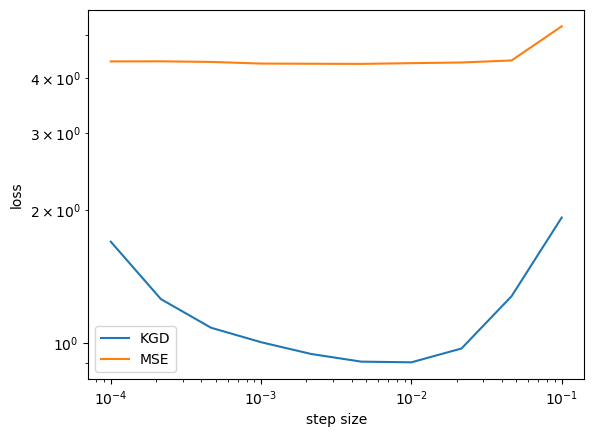

In [84]:
# Evaluate KGDs for obtained particles
scale = 1
# k = jit(lambda x, y: k_imq(x/scale, y/scale, 1, 0.5) + x.dot(y))
# k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))
k = jit( lambda x, y: imq_scale_mixtures(x, y, jnp.logspace(-2, 2, 5)))
# k = lambda x, y: x.dot(y)
# k_pq = GradientKernel(score, k)
# kgds = [kgdd.kgd(final_particles[e]) for e in range(num_stepsizes)]
kgds = [kgd_(final_particles[e]) for e in range(num_stepsizes)]
kgds = jnp.array(kgds)
mses = jnp.array( [L_(final_particles[e]) for e in range(num_stepsizes)])
plt.xlabel('step size')
plt.ylabel('loss')
plt.yscale('log')
plt.xscale('log')
plt.plot(etas, kgds, label='KGD')
plt.plot(etas, mses, label='MSE')
plt.legend()
plt.show()
# median_kgd = jnp.median(kgds, axis=0)
# kgd_ci_low = jnp.quantile(kgds, ql, axis=0)
# kgd_ci_high = jnp.quantile(kgds, qr, axis=0)

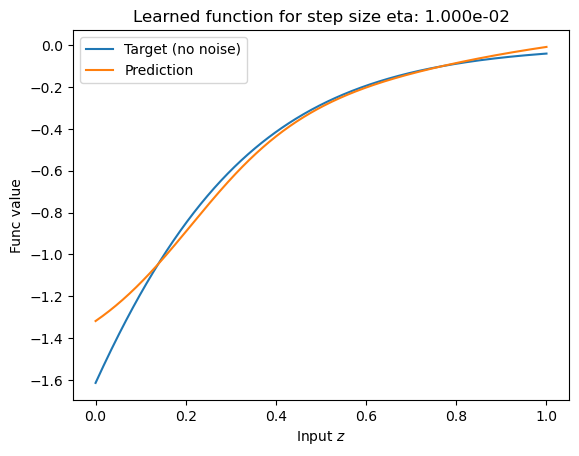

In [85]:
ntestpoints = 400
Ztest = jnp.linspace(0, 1, ntestpoints).reshape(-1, 1)
target_values = target_function(Ztest)
i_eta = jnp.argmin(kgds) # step size's index
# predictions =  (lambda i: vmap(lambda z: forward_(final_particles[i_eta], z, unravel_fn))(Ztest))(jnp.arange(n_sim))
predictions =  vmap(lambda z: forward_(final_particles[i_eta], z, unravel_fn))(Ztest)

plt.plot(Ztest, target_values, label='Target (no noise)')
plt.plot(Ztest, predictions, label='Prediction')
plt.xlabel('Input $z$')
plt.ylabel('Func value')
plt.title('Learned function for step size eta: {0:.3e}'.format(etas[i_eta]))
plt.legend()
plt.show()

In [86]:
gradL(final_particles[i_eta])

Array([[ 1.9034529e+00,  3.3509412e+00, -1.4825252e+00,  1.0646591e+00],
       [-1.1631947e+00, -1.2255064e+00,  3.1983614e-02,  1.0646591e+00],
       [-1.1413141e+00, -2.1503906e+00,  8.9711285e-01,  1.0646591e+00],
       [ 7.4408979e+00,  8.9059696e+00, -3.2214952e+00,  1.0646591e+00],
       [-8.4105062e-01, -4.1764446e-02,  1.0203096e+00,  1.0646591e+00],
       [ 4.5904055e+00,  2.8036549e+00, -3.6339281e+00,  1.0646591e+00],
       [ 4.1538072e-01,  2.5396883e-01, -2.7110684e+00,  1.0646591e+00],
       [-4.4286880e+00, -4.5113297e+00,  3.2638049e+00,  1.0646591e+00],
       [-4.6390748e+00, -6.9146810e+00,  1.9471452e+00,  1.0646591e+00],
       [-1.1559975e+00, -3.4718114e-01,  1.2767253e+00,  1.0646591e+00],
       [ 6.3371563e-01,  7.4110931e-01, -2.5222564e-01,  1.0646591e+00],
       [-1.0076461e+00, -5.5577499e-01,  4.8853737e-01,  1.0646591e+00],
       [ 2.7691441e-02,  5.6412268e-01, -1.1786452e-02,  1.0646591e+00],
       [ 7.9088432e-01,  8.7300909e-01, -1.4632845e

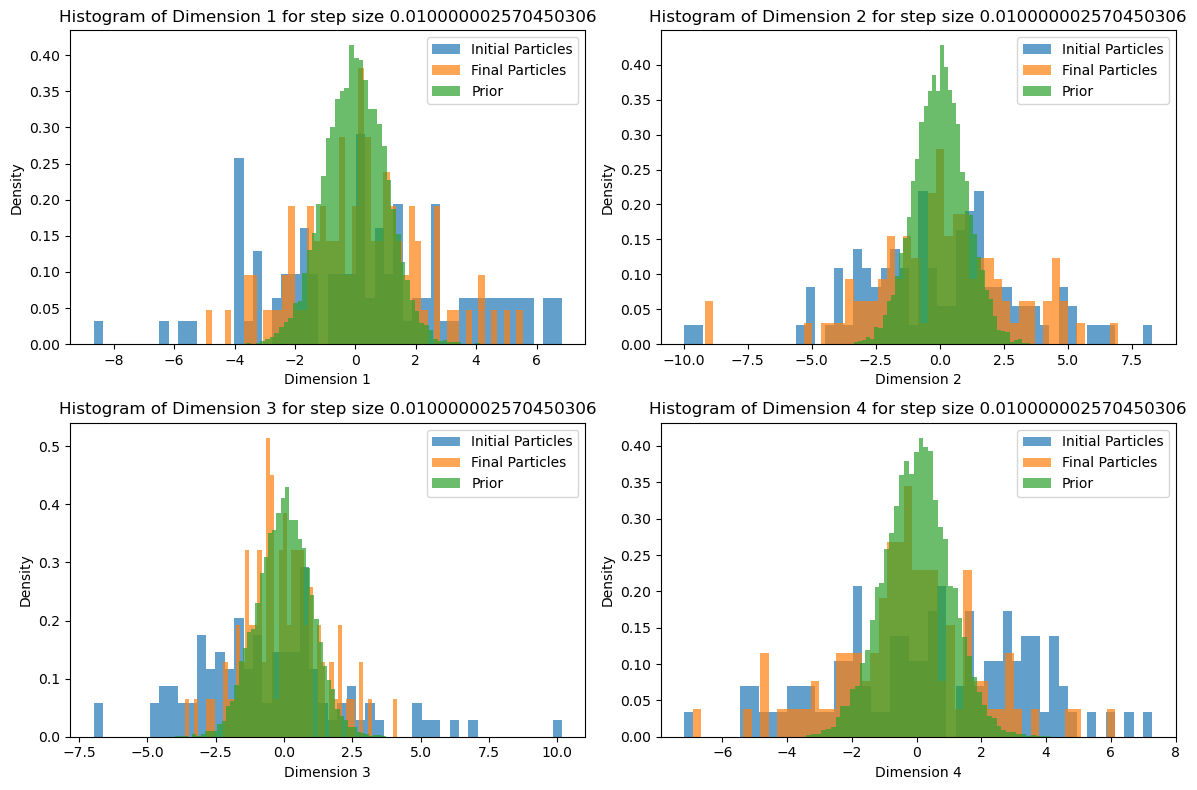

In [87]:
plt.figure(figsize=(12, 8))
prior_mass = random.normal(key, shape=(10000, d))

for i in range(d):
    plt.subplot(2, 2, i + 1)
    plt.hist(X0[:, i], bins=50, density=True, alpha=0.7, label='Initial Particles')
    plt.hist(final_particles[i_eta, :, i], bins=50, density=True, alpha=0.7, label='Final Particles')
    plt.hist(prior_mass[:, i], bins=50, density=True, alpha=0.7, label='Prior')
    plt.xlabel(f'Dimension {i + 1}')
    plt.ylabel('Density')
    plt.title(f'Histogram of Dimension {i + 1} for step size {etas[i_eta]}')
    plt.legend()

plt.tight_layout()
plt.show()

In [88]:
def mmd(k, X, Y):
  Kxx = vmap( lambda x: vmap( lambda y: k(x, y))(X))(X)
  Kyy = vmap( lambda x: vmap( lambda y: k(x, y))(Y))(Y)
  Kxy = vmap( lambda x: vmap( lambda y: k(x, y))(Y))(X)
  return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

mmd( lambda x, y: k_imq(x, y, 1, 0.5, 10), X0, final_particles[i_eta])

Array(0.01648629, dtype=float32)

In [89]:
eta = etas[i_eta]
particles_opt = kgd_descent_adam(kgd_, X0, eta, T)
F = particles_opt[-1]

Step 0, loss = 300.4704284667969, mse = 1.268000841140747
Step 10, loss = 224.66058349609375, mse = 0.766769528388977
Step 20, loss = 150.709228515625, mse = 0.4132271111011505
Step 30, loss = 78.20967864990234, mse = 0.20626108348369598
Step 40, loss = 16.116762161254883, mse = 0.14603546261787415
Step 50, loss = 25.997987747192383, mse = 0.15029124915599823
Step 60, loss = 15.812621116638184, mse = 0.14055709540843964
Step 70, loss = 14.437813758850098, mse = 0.13625480234622955
Step 80, loss = 14.111832618713379, mse = 0.13199688494205475
Step 90, loss = 13.365569114685059, mse = 0.12678925693035126
Step 100, loss = 12.688820838928223, mse = 0.12209109216928482
Step 110, loss = 12.110064506530762, mse = 0.11708489805459976
Step 120, loss = 11.586576461791992, mse = 0.11240358650684357
Step 130, loss = 11.096181869506836, mse = 0.10773635655641556
Step 140, loss = 10.633066177368164, mse = 0.1032714918255806
Step 150, loss = 10.194207191467285, mse = 0.09890458732843399
Step 160, los

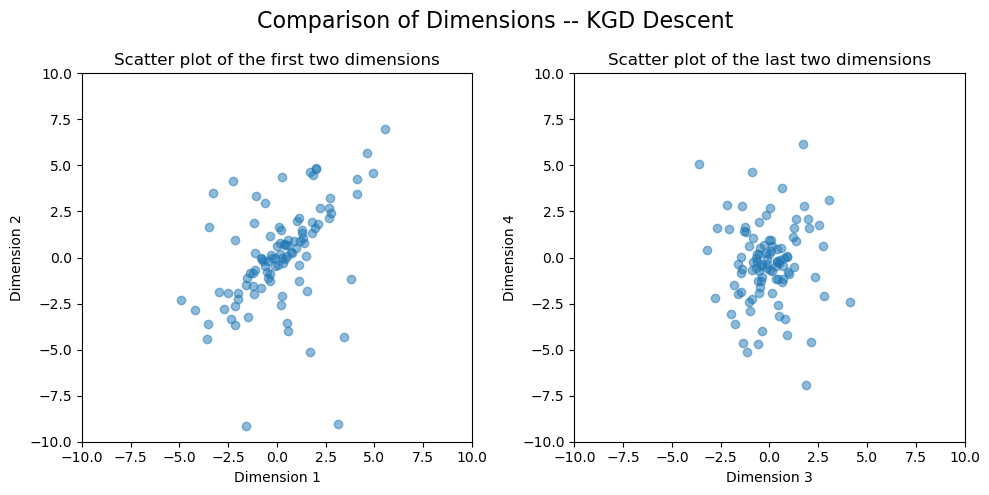

In [90]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# First scatter plot
axes[0].scatter(F[:, 0], F[:, 1], alpha=0.5)
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-10, 10)
axes[0].set_xscale('linear')
axes[0].set_yscale('linear')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].set_title('Scatter plot of the first two dimensions')

# Second scatter plot
axes[1].scatter(F[:, 2], F[:, 3], alpha=0.5)
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(-10, 10)
axes[1].set_xscale('linear')
axes[1].set_yscale('linear')
axes[1].set_xlabel('Dimension 3')
axes[1].set_ylabel('Dimension 4')
axes[1].set_title('Scatter plot of the last two dimensions')
fig.suptitle("Comparison of Dimensions -- KGD Descent", fontsize=16)
plt.tight_layout()
plt.show()

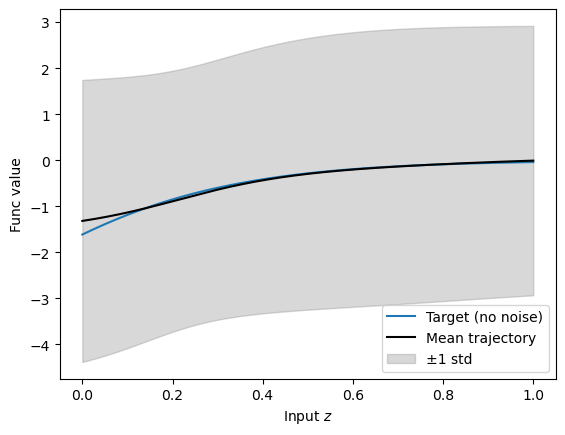

In [91]:
N = len(F)
ntestpoints = 400
Ztest = jnp.linspace(0, 1, ntestpoints).reshape(-1, 1)
target_values = target_function(Ztest)
predictions = vmap(lambda i: vmap(lambda z: forward_(F[None, i, :], z, unravel_fn))(Ztest))(jnp.arange(N))

mean = predictions.mean(axis=0)
std = predictions.std(axis=0)
plt.plot(Ztest.squeeze(), target_values, label='Target (no noise)')
plt.plot(Ztest.squeeze(), mean, color="k", label="Mean trajectory")
plt.fill_between(Ztest.squeeze(), mean - std, mean + std,
                 color="gray", alpha=0.3, label="±1 std")
# plt.heatmap(predictions, cmap="viridis", cbar=True)

# plt.plot(Ztest, prediction, label='Prediction')
plt.xlabel('Input $z$')
plt.ylabel('Func value')
# plt.title('Learned function for step size eta: {0:.3e}'.format(etas[i_eta]))
plt.legend()
plt.show()

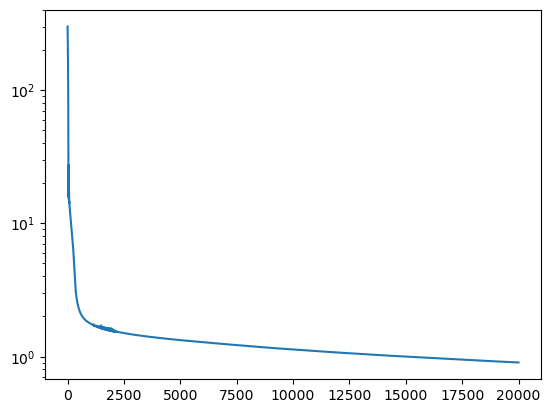

In [92]:
KGD_values = []
for it in range(T):
    KGD_values.append(kgd_(particles_opt[it]))
plt.plot( KGD_values)
plt.yscale('log')


In [49]:
final_particles.shape

(10, 100, 4)

In [93]:
import pickle

with open("results_heishiro.pkl", "rb") as g:
    results_heishiro = pickle.load(g)

In [94]:
results_heishiro["KGD Descent"]["X_fin"] = F
KGD_values = jnp.array(KGD_values)
results_heishiro["KGD Descent"]["KGD_values"] = jnp.sqrt(KGD_values)

In [95]:
import pickle

with open("results_heishiro.pkl", "wb") as g:
    pickle.dump(results_heishiro, g)